# Model comparison: fitted GP vs distance-blind (flat) GP

Two models of the Study 9 ratings, identical in every respect except the length scale:

- **fitted**: posterior-median theta from `results/<RESULTS_NAME>/` (fitted-shapes posterior) —
  coherence generalizes locally in embedding space.
- **flat** (distance-blind null): same `mu_0` and `sigma`, but `length_scale = LS_FLAT` (>> the
  feature-cloud diameter ~0.78), so the kernel is effectively constant: training a region elevates
  coherence UNIFORMLY across the embedding, i.e. generalization exists but is not based on
  embedding-space distance. (The other degenerate limit, ls -> 0, would be fully independent
  features with no transfer at all.)

Both models get the same treatment as the main inference: per-feature linking shapes SHARED across
conditions, profiled at each theta from the ratings-free coherence mode
(`inference.total_log_lik_free_shapes`). The comparison metric is the summed Laplace marginal
likelihood `log Z` (equal parameter counts, so the raw difference is the point log-likelihood
ratio).

Caveat until the planned refit: the flat model borrows `(mu_0, sigma)` from the FITTED run rather
than its own maximum — so the flat model is mildly handicapped. Refitting `(mu_0, sigma)` at fixed
`LS_FLAT` (e.g. via `inf.run_vbmc_free_shapes` with a pinned first coordinate) is the follow-up.

In [1]:
RESULTS_NAME = 'study9-vbmc-laplace'   # results subdirectory under ./results
DATA_CSV     = '../../data/study9.csv'
LS_FLAT      = 10.0                     # >> cloud diameter ~0.78 -> effectively constant kernel

import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ.setdefault("JAX_ENABLE_X64", "1")
import sys
sys.path.insert(0, ".")

import json
import numpy as np
import matplotlib.pyplot as plt

import inference as inf

RESULTS_DIR = os.path.join('results', RESULTS_NAME)
z = np.load(os.path.join(RESULTS_DIR, 'posterior-fitted-shapes.npz'), allow_pickle=True)
LS_FIT, MU0, SIGMA = (float(np.median(z['ls_samples'])), float(np.median(z['mu0_samples'])),
                      float(np.median(z['sigma_samples'])))

MODELS = {
    'fitted': {'ls': LS_FIT,  'mu_0': MU0, 'sigma': SIGMA},
    'flat':   {'ls': LS_FLAT, 'mu_0': MU0, 'sigma': SIGMA},
}
for name, m in MODELS.items():
    print(f"  {name:<7}: ls={m['ls']:<6g} mu_0={m['mu_0']:+.3f}  sigma={m['sigma']:.3f}")

geom = inf.load_geometry()
J = geom['J']
responses_cond, _ = inf.load_responses(DATA_CSV)
emp_cond = {c: np.array(responses_cond[c]).mean(0) for c in inf.CONDITIONS}
N_cond   = {c: int(responses_cond[c].shape[0]) for c in inf.CONDITIONS}

  fitted : ls=0.263999 mu_0=-0.014  sigma=0.570
  flat   : ls=10     mu_0=-0.014  sigma=0.570


## Likelihood comparison

Per-condition and total Laplace `log Z`, with the linking shapes profiled independently under each
model (same one-shot procedure), plus forward-pass predicted-vs-empirical correlations.

In [2]:
fitres = {}
for name, m in MODELS.items():
    ll, shapes, cond_data = inf.total_log_lik_free_shapes(
        geom, responses_cond, m['ls'], m['mu_0'], m['sigma'], return_shapes=True)
    logZ_c = {c: inf.laplace_log_Z(cond_data[c], m['ls'], m['mu_0'], m['sigma'])[0]
              for c in inf.CONDITIONS}
    # forward pass: pz1 mode per condition under this model's shapes -> predicted E[rating]
    mean_kl  = shapes[:, 0] / (shapes[:, 0] + shapes[:, 1])
    mean_nkl = shapes[:, 2] / (shapes[:, 2] + shapes[:, 3])
    pred_cond, pz1_cond = {}, {}
    for c in inf.CONDITIONS:
        _, y_hat, _ = inf.laplace_log_Z(cond_data[c], m['ls'], m['mu_0'], m['sigma'])
        pz1_cond[c]  = 1.0 / (1.0 + np.exp(-y_hat[:J]))
        pred_cond[c] = pz1_cond[c]*mean_kl + (1-pz1_cond[c])*mean_nkl
    fitres[name] = {'ll': ll, 'logZ_c': logZ_c, 'shapes': shapes,
                    'pred_cond': pred_cond, 'pz1_cond': pz1_cond}

print(f"{'condition':<15}{'fitted logZ':>13}{'flat logZ':>12}{'delta':>9}")
for c in inf.CONDITIONS:
    d = fitres['fitted']['logZ_c'][c] - fitres['flat']['logZ_c'][c]
    print(f"{c:<15}{fitres['fitted']['logZ_c'][c]:>13.1f}{fitres['flat']['logZ_c'][c]:>12.1f}{d:>+9.1f}")
delta = fitres['fitted']['ll'] - fitres['flat']['ll']
print(f"{'TOTAL':<15}{fitres['fitted']['ll']:>13.1f}{fitres['flat']['ll']:>12.1f}{delta:>+9.1f}")
print(f"\nlog likelihood ratio (fitted - flat): {delta:+.1f}"
      f"   (equal param counts; >0 favors embedding-based generalization)")

print(f"\n{'condition':<15}{'r fitted':>10}{'r flat':>10}   (predicted vs empirical mean rating)")
for c in inf.CONDITIONS:
    rs = {n: np.corrcoef(fitres[n]['pred_cond'][c], emp_cond[c])[0, 1] for n in MODELS}
    print(f"{c:<15}{rs['fitted']:>+10.3f}{rs['flat']:>+10.3f}")
emp_all = np.concatenate([emp_cond[c] for c in inf.CONDITIONS])
for n in MODELS:
    r_pool = np.corrcoef(np.concatenate([fitres[n]['pred_cond'][c] for c in inf.CONDITIONS]), emp_all)[0, 1]
    print(f"pooled r ({n}): {r_pool:+.3f}")

condition        fitted logZ   flat logZ    delta
diet                   198.8       196.8     +2.0
personality            200.5       190.9     +9.6
physical               349.8       349.7     +0.1
heterogeneous          158.8       160.0     -1.2
TOTAL                  907.9       897.5    +10.4

log likelihood ratio (fitted - flat): +10.4   (equal param counts; >0 favors embedding-based generalization)

condition        r fitted    r flat   (predicted vs empirical mean rating)
diet               +0.972    +0.936
personality        +0.982    +0.949
physical           +0.953    +0.874
heterogeneous      +0.977    +0.941
pooled r (fitted): +0.961
pooled r (flat): +0.915


## Coherence fields

Same visualization as `plot-gp-coherence-field.ipynb`, one figure per model. Under the flat model
the field is constant (range < 1e-3), so its panels use a fixed +-0.05 color window around the
flat value — visibly uniform, which is the point.

saved results\study9-vbmc-laplace\gp-coherence-field-fitted.png


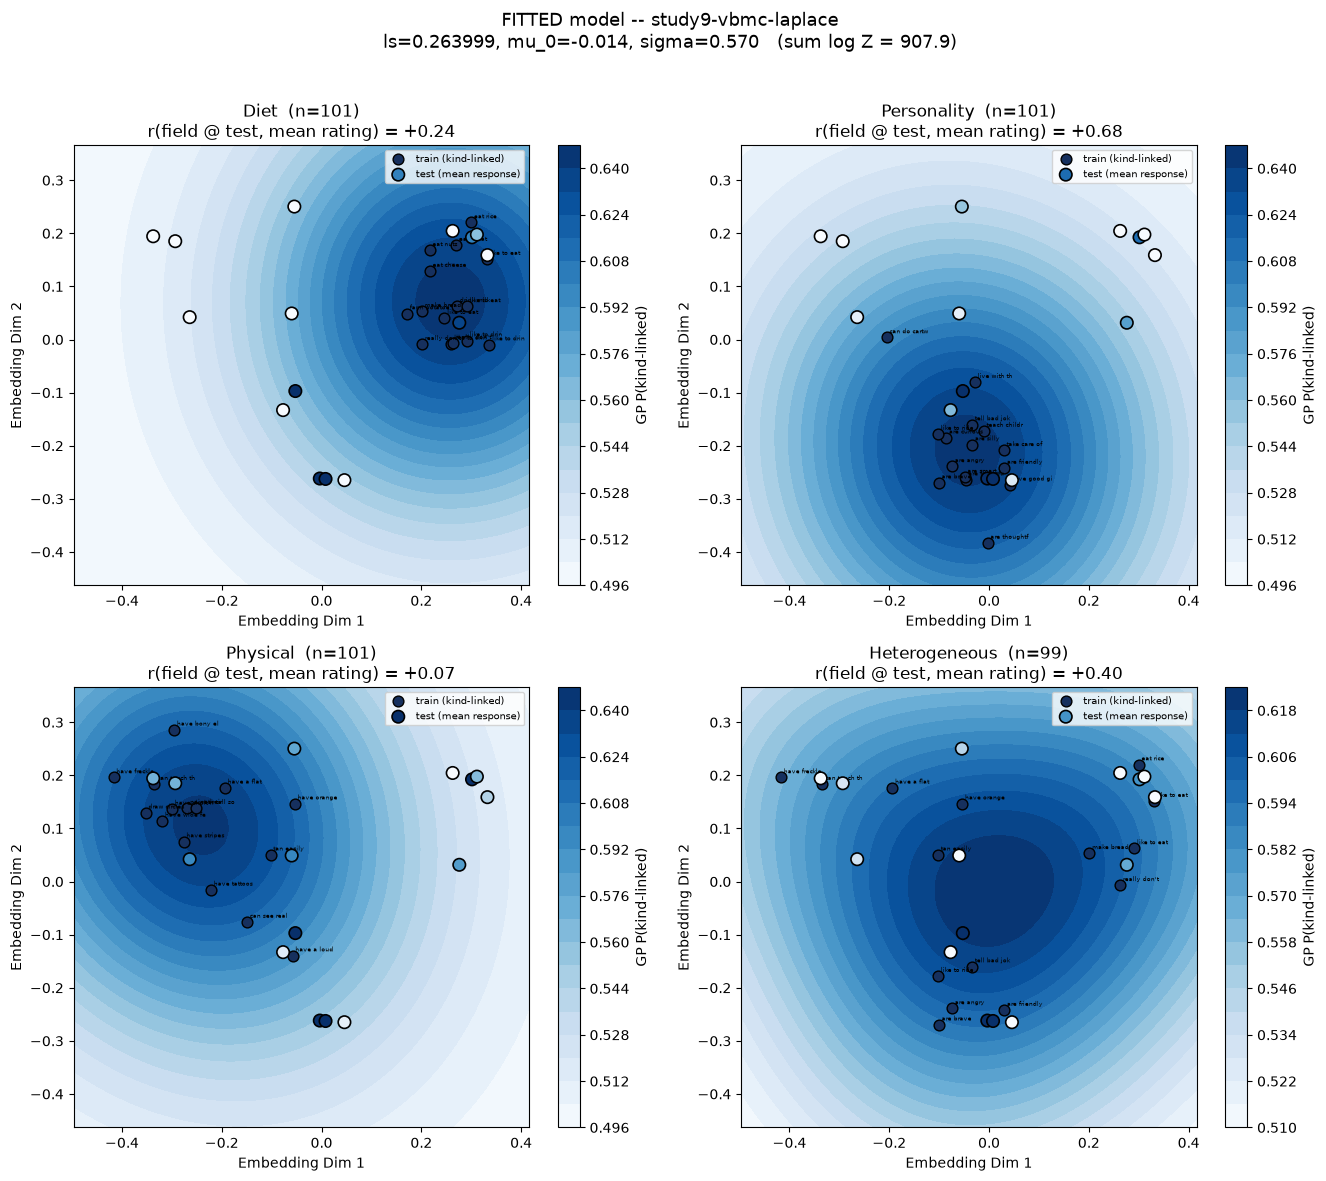

In [3]:
all_x = np.vstack([np.array(geom['x_test'])] + [np.array(geom['x_train_cond'][c]) for c in inf.CONDITIONS])
pad = 0.08
(x_lo, y_lo), (x_hi, y_hi) = all_x.min(0) - pad, all_x.max(0) + pad
gx, gy = np.meshgrid(np.linspace(x_lo, x_hi, 80), np.linspace(y_lo, y_hi, 80))
X_grid = np.column_stack([gx.ravel(), gy.ravel()])
x_test_np = np.array(geom['x_test'])

def plot_fields(name, m):
    fig, axes = plt.subplots(2, 2, figsize=(13.5, 12))
    for ax, c in zip(axes.ravel(), inf.CONDITIONS):
        field    = inf.gp_coherence_field(geom, c, m['ls'], m['mu_0'], m['sigma'], X_grid).reshape(gx.shape)
        pz1_test = inf.gp_coherence_field(geom, c, m['ls'], m['mu_0'], m['sigma'], x_test_np)
        if np.ptp(field) < 1e-3:   # flat model: fix a readable color window around the constant
            levels = np.linspace(field.mean() - 0.05, field.mean() + 0.05, 21)
        else:
            levels = 20
        cs = ax.contourf(gx, gy, field, levels=levels, cmap='Blues')
        cb = fig.colorbar(cs, ax=ax); cb.set_label('GP P(kind-linked)')

        x_tr = np.array(geom['x_train_cond'][c])
        ax.scatter(x_tr[:, 0], x_tr[:, 1], s=60, color='#16305e', edgecolor='k',
                   zorder=3, label='train (kind-linked)')
        for (xx, yy), nm in zip(x_tr, geom['train_names_cond'][c]):
            ax.annotate(nm[:12], (xx, yy), fontsize=4, xytext=(2, 3), textcoords='offset points')
        ax.scatter(x_test_np[:, 0], x_test_np[:, 1], s=80, c=emp_cond[c], cmap='Blues', norm=cs.norm,
                   edgecolor='k', linewidth=1.2, zorder=3, label='test (mean response)')

        if np.ptp(pz1_test) > 1e-3:
            r_txt = f"r(field @ test, mean rating) = {np.corrcoef(pz1_test, emp_cond[c])[0, 1]:+.2f}"
        else:
            r_txt = 'field ~ constant (r undefined)'
        ax.set_title(f"{c.capitalize()}  (n={N_cond[c]})\n{r_txt}")
        ax.set_xlabel('Embedding Dim 1'); ax.set_ylabel('Embedding Dim 2')
        ax.legend(fontsize=7, loc='upper right')
    fig.suptitle(f"{name.upper()} model -- {RESULTS_NAME}\n"
                 f"ls={m['ls']:g}, mu_0={m['mu_0']:+.3f}, sigma={m['sigma']:.3f}   "
                 f"(sum log Z = {fitres[name]['ll']:.1f})", fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.965])
    out_png = os.path.join(RESULTS_DIR, f'gp-coherence-field-{name}.png')
    fig.savefig(out_png, dpi=150, bbox_inches='tight')
    print('saved', out_png)
    plt.show()

plot_fields('fitted', MODELS['fitted'])

saved results\study9-vbmc-laplace\gp-coherence-field-flat.png


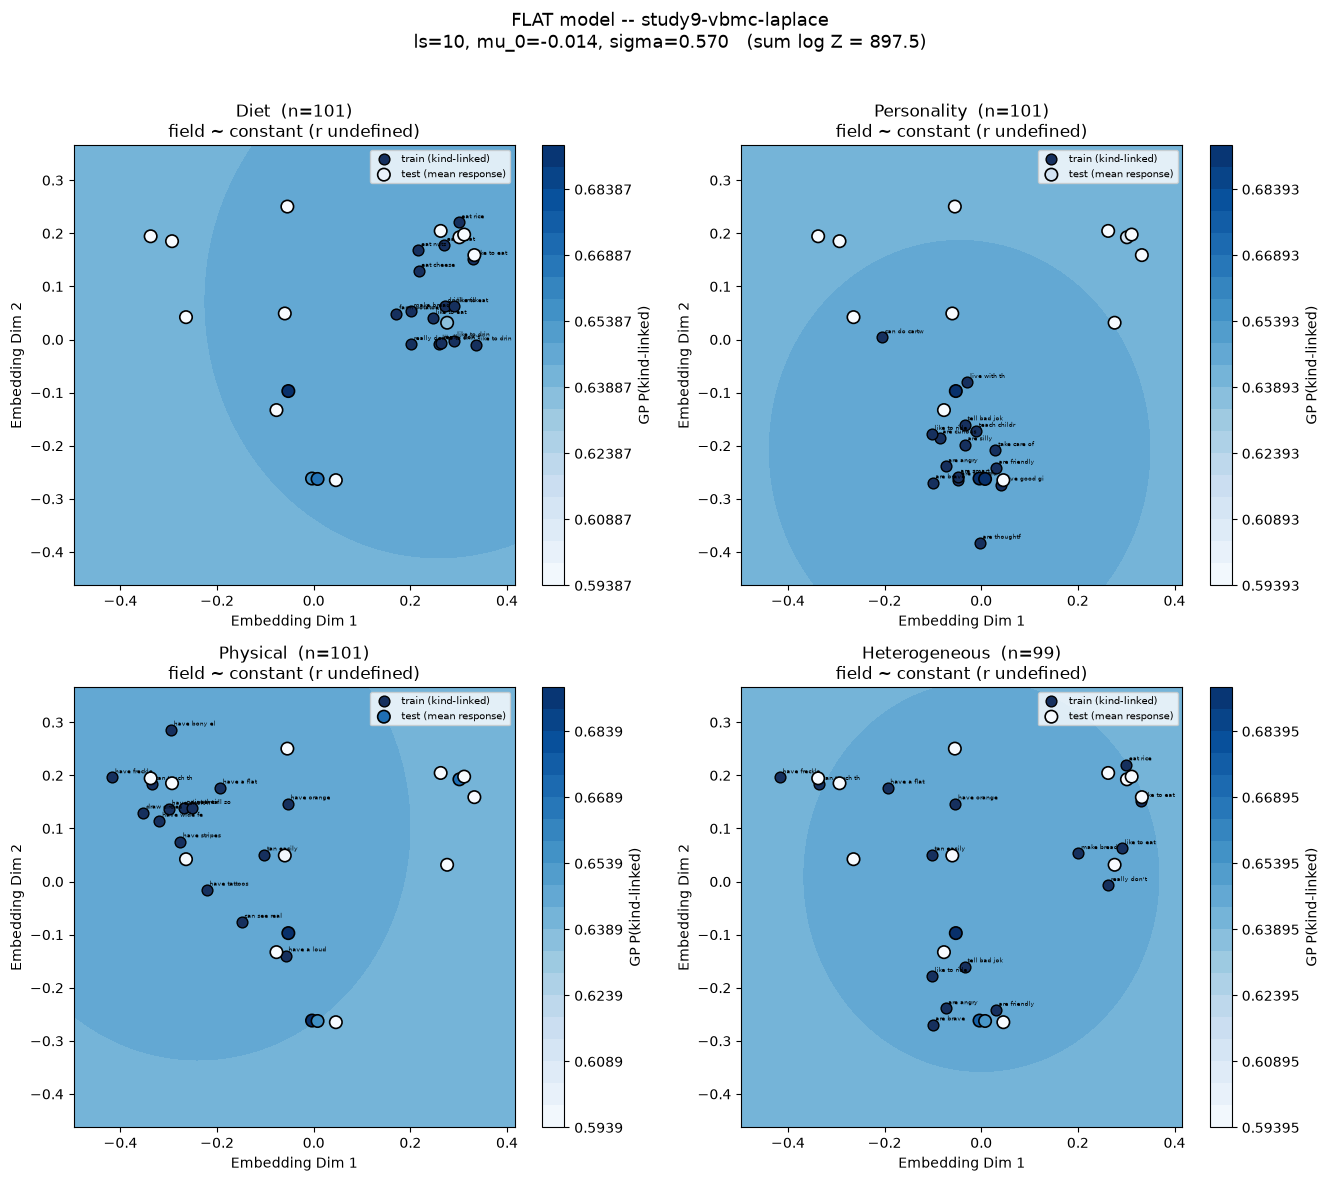

In [4]:
plot_fields('flat', MODELS['flat'])